In [1]:
!pip install wbgapi openpyxl --quiet

In [2]:
import pandas as pd
import sqlite3
import wbgapi as wb
import requests
from google.colab import files
import numpy as np

# Cleaning

In [3]:
uploaded = files.upload()

filename = list(uploaded.keys())[0]

Saving PET_PRI_GND_DCUS_NUS_W.xls to PET_PRI_GND_DCUS_NUS_W.xls


In [4]:
peek = pd.read_excel(filename, sheet_name='Data 1', header=None, nrows=10)
header_row = peek[peek[0] == 'Date'].index[0]

In [5]:
# Rename date column
# Drop rows where date is null
# Parse dates
raw = pd.read_excel(filename, sheet_name='Data 1', skiprows=header_row, header=0)
raw = raw.loc[:, ~raw.columns.str.startswith('Unnamed')]
raw.rename(columns={raw.columns[0]: 'date'}, inplace=True)
raw = raw.dropna(subset=['date'])
raw['date'] = pd.to_datetime(raw['date'], errors='coerce')
raw = raw.dropna(subset=['date'])

In [6]:
def find_col(df, keyword):
    matches = [c for c in df.columns if keyword.lower() in c.lower()]
    return matches[0] if matches else None

In [7]:
col_all_grades = find_col(raw, 'All Grades All Formulations Retail Gasoline')
col_regular    = find_col(raw, 'Regular All Formulations Retail Gasoline')
col_diesel     = find_col(raw, 'No 2 Diesel Retail Prices')

In [8]:
keep = {'date': 'date'}
if col_all_grades: keep[col_all_grades] = 'us_all_grades'
if col_regular:    keep[col_regular]    = 'us_regular'
if col_diesel:     keep[col_diesel]     = 'us_diesel'

In [9]:
eia = raw[list(keep.keys())].rename(columns=keep)
eia['year_month'] = eia['date'].dt.to_period('M').astype(str)

In [10]:
eia.head(5)

,date,us_all_grades,us_regular,us_diesel,year_month
0,1990-08-20,NaN,1.191,NaN,1990-08
1,1990-08-27,NaN,1.245,NaN,1990-08
2,1990-09-03,NaN,1.242,NaN,1990-09
3,1990-09-10,NaN,1.252,NaN,1990-09
4,1990-09-17,NaN,1.266,NaN,1990-09


# World Bank Data

Loading Data

In [11]:
API_KEY = "EIA_API_KEY"  # API key

# Brent crude monthly spot price from EIA
url = (
    "https://api.eia.gov/v2/petroleum/pri/spt/data/"
    f"?api_key={API_KEY}"
    "&frequency=monthly"
    "&data[0]=value"
    "&facets[series][]=RBRTE"
    "&sort[0][column]=period"
    "&sort[0][direction]=asc"
    "&length=2000"
)

In [12]:
r = requests.get(url, timeout=30)
print("Status:", r.status_code)

payload = r.json()
records = payload.get('response', {}).get('data', [])
print(f"Records returned: {len(records)}")

brent = pd.DataFrame([{
    'year_month': rec['period'],
    'brent_usd_bbl': rec['value']
} for rec in records])


Status: 200
Records returned: 466


In [13]:
brent.head()

,year_month,brent_usd_bbl
0,1987-05,18.58
1,1987-06,18.86
2,1987-07,19.86
3,1987-08,18.98
4,1987-09,18.31


# SQL Setup

In [14]:
conn = sqlite3.connect("energy_prices.db")

In [15]:
# Load tables
eia.to_sql("eia_us_prices", conn, if_exists="replace", index=False)
brent.to_sql("brent_crude", conn, if_exists="replace", index=False)

466

In [16]:
print("Tables loaded:")
for (name,) in conn.execute("SELECT name FROM sqlite_master WHERE type='table'"):
    count = conn.execute(f"SELECT COUNT(*) FROM {name}").fetchone()[0]
    print(f"  {name}: {count} rows")

Tables loaded:
  eia_us_prices: 1855 rows
  brent_crude: 466 rows


# Queries

In [17]:
# Queries
query = """
SELECT
    e.year_month,
    ROUND(AVG(COALESCE(e.us_all_grades, e.us_regular)), 3) AS avg_us_pump,
    ROUND(AVG(e.us_regular), 3)                            AS avg_us_regular,
    ROUND(MAX(b.brent_usd_bbl), 2)                         AS brent_usd_bbl
FROM eia_us_prices e
LEFT JOIN brent_crude b USING (year_month)
WHERE e.year_month IN (
    -- baseline periods
    '2002-01', '2003-01',
    -- Gulf War II / run-up
    '2004-06', '2005-06',
    -- 2008 peak
    '2008-06', '2008-07',
    -- post crisis low
    '2009-02',
    -- COVID low
    '2020-04',
    -- Ukraine shock
    '2022-03', '2022-06',
    -- pre Iran war
    '2026-01', '2026-02'
)
GROUP BY e.year_month
ORDER BY e.year_month
"""

result = pd.read_sql_query(query, conn)
print("\nShock period spot check:")
print(result.to_string(index=False))


Shock period spot check:
year_month  avg_us_pump  avg_us_regular  brent_usd_bbl
   2002-01        1.148           1.107          19.42
   2003-01        1.500           1.458          31.18
   2004-06        2.013           1.969          35.18
   2005-06        2.198           2.156          54.35
   2008-06        4.105           4.054         132.32
   2008-07        4.114           4.062         132.72
   2009-02        1.975           1.923          43.32
   2020-04        1.938           1.841          18.38
   2022-03        4.322           4.222         117.25
   2022-06        5.032           4.929         122.71
   2026-01        2.936           2.809          66.60
   2026-02        3.039           2.908          70.89


In [18]:
# Query US Oil Price Per Gallon
query1 = """
select avg(us_regular) as avg_price, year_month
FROM eia_us_prices
where us_regular is not null
group by year_month
order by year_month
"""

result = pd.read_sql_query(query1, conn)

In [19]:
import matplotlib.pyplot as plt

df1 = pd.read_sql_query(query1, conn)
df1['year_month'] = pd.to_datetime(df1['year_month'])

In [20]:
# Query Brent Oil Price Per Barrel
query2 = """
select*
from brent_crude
order by year_month
"""

result = pd.read_sql_query(query2, conn)

In [21]:
df2 = pd.read_sql_query(query2, conn)
df2['year_month'] = pd.to_datetime(df2['year_month'])
df2['brent_usd_bbl'] = df2['brent_usd_bbl'].astype(float)

Text(2022-09-01 00:00:00, 60, 'Ukraine\nWar')

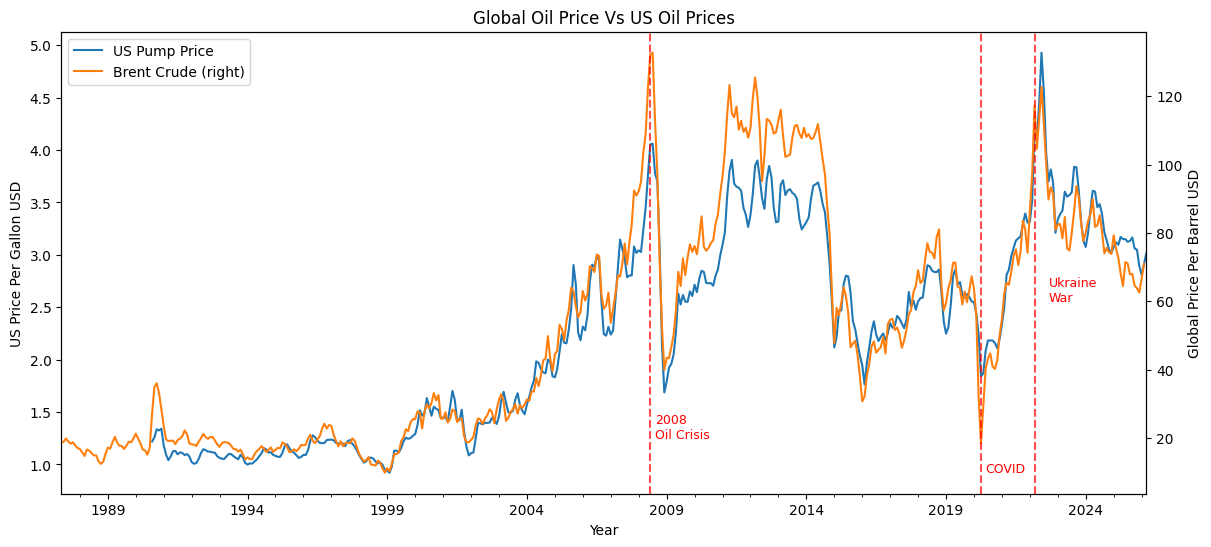

In [22]:
ax1 = df1.plot('year_month', 'avg_price',
               title = "Global Oil Price Vs US Oil Prices",
               figsize=(14,6), label='US Pump Price',
               ylabel = "US Price Per Gallon USD")

df2.plot('year_month', 'brent_usd_bbl',
         ax=ax1, secondary_y=True, label='Brent Crude',
         ylabel = "Global Price Per Barrel USD", xlabel = 'Year')

plt.axvline(pd.Timestamp('2008-06'), color='red', linestyle='--', alpha=0.7)
plt.text(pd.Timestamp('2008-06') + pd.DateOffset(months= 2), 20, '2008\nOil Crisis', color='red', fontsize=9)

plt.axvline(pd.Timestamp('2020-04'), color='red', linestyle='--', alpha=0.7)
plt.text(pd.Timestamp('2020-04') + pd.DateOffset(months= 2), 10, 'COVID', color='red', fontsize=9)

plt.axvline(pd.Timestamp('2022-03'), color='red', linestyle='--', alpha=0.7)
plt.text(pd.Timestamp('2022-03') + pd.DateOffset(months=6), 60, 'Ukraine\nWar', color='red', fontsize=9)

In [23]:
# Query US/Brent Ratio
query3 = """
select avg_us*42/avg_brent as ratio, year_month
from(
select
  avg(e.us_regular) as avg_us,
  avg(b.brent_usd_bbl) as avg_brent,
  e.year_month
from eia_us_prices as e
join brent_crude as b on e.year_month = b.year_month
where us_regular is not null
group by e.year_month) as monthly_avg
order by year_month

"""

result = pd.read_sql_query(query3, conn)

In [24]:
df3 = pd.read_sql_query(query3, conn)
df3['year_month'] = pd.to_datetime(df2['year_month'])
df3['ratio'] = df3['ratio'].astype(float)

Text(2022-01-01 00:00:00, 2.5, 'Ukraine\nWar')

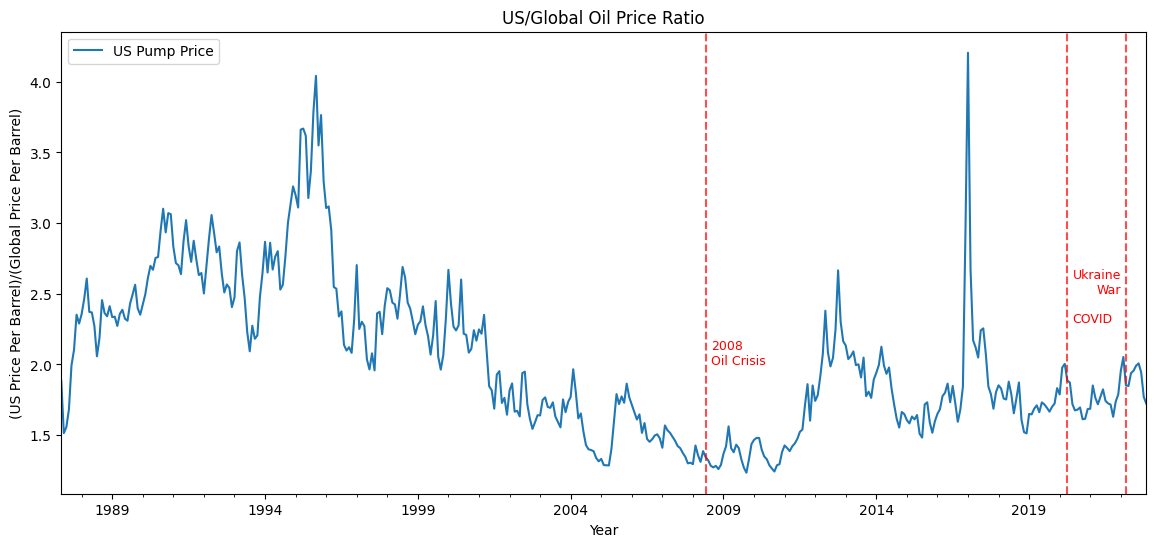

In [25]:
df3.plot('year_month', 'ratio',
               title = "US/Global Oil Price Ratio",
               figsize=(14,6), label='US Pump Price',
               ylabel = "(US Price Per Barrel)/(Global Price Per Barrel)",
               xlabel = "Year")

plt.axvline(pd.Timestamp('2008-06'), color='red', linestyle='--', alpha=0.7)
plt.text(pd.Timestamp('2008-06') + pd.DateOffset(months= 2), 2, '2008\nOil Crisis', color='red', fontsize=9)

plt.axvline(pd.Timestamp('2020-04'), color='red', linestyle='--', alpha=0.7)
plt.text(pd.Timestamp('2020-04') + pd.DateOffset(months= 2), 2.3, 'COVID', color='red', fontsize=9)

plt.axvline(pd.Timestamp('2022-03'), color='red', linestyle='--', alpha=0.7)
plt.text(pd.Timestamp('2022-03') - pd.DateOffset(months=2), 2.5, 'Ukraine\nWar', color='red', fontsize=9, ha='right')

# Rockets and Feathers Comparison

https://fredblog.stlouisfed.org/2022/06/oil-and-gas-prices-move-together-like-rockets-and-feathers/

In [26]:
# Query US Brent LAG
query4 = """
select*,
   (avg_us - LAG(avg_us) over (order by year_month))*42 as pump_change,
   avg_brent - LAG(avg_brent) over (order by year_month) as brent_change
from
(select
  avg(e.us_regular) as avg_us,
  avg(b.brent_usd_bbl) as avg_brent,
  e.year_month
from eia_us_prices as e
join brent_crude as b on e.year_month = b.year_month
where us_regular is not null
group by e.year_month) as monthly_avg

"""

result = pd.read_sql_query(query4, conn)

In [27]:
df4 = pd.read_sql_query(query4, conn)
df4['year_month'] = pd.to_datetime(df2['year_month'])

Text(0.5, 1.0, 'Rockets & Feathers: Brent vs US Pump Price Changes')

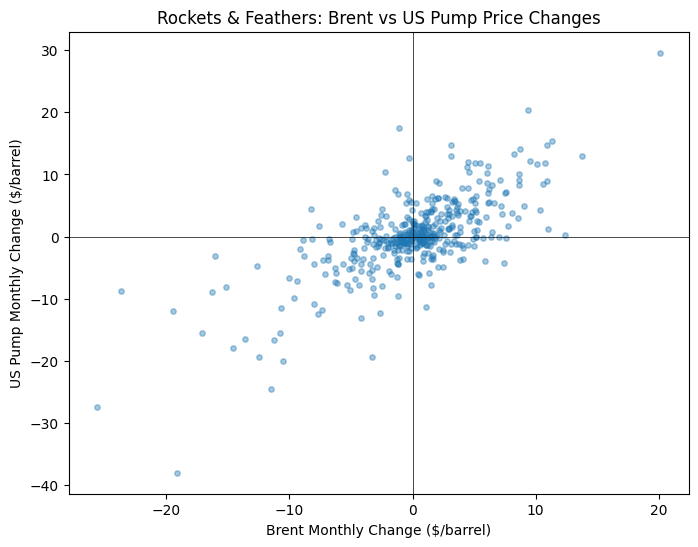

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(df4['brent_change'], df4['pump_change'], alpha=0.4, s=15)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.xlabel('Brent Monthly Change ($/barrel)')
plt.ylabel('US Pump Monthly Change ($/barrel)')
plt.title('Rockets & Feathers: Brent vs US Pump Price Changes')

In [29]:
up = df4[df4['brent_change'] > 0].dropna().copy()
down = df4[df4['brent_change'] < 0].dropna().copy()

up['pump_change_bbl'] = up['pump_change'] * 42
down['pump_change_bbl'] = down['pump_change'] * 42

m_up, b_up = np.polyfit(up['brent_change'], up['pump_change_bbl'], 1)
m_down, b_down = np.polyfit(down['brent_change'], down['pump_change_bbl'], 1)

print("Slop When print rises: ", m_up, " | ", "Slope when brent falls: ", m_down)



Slop When print rises:  41.43386380034797  |  Slope when brent falls:  39.688160202277814


# Shock Calculation

https://www.federalreserve.gov/econres/notes/feds-notes/oil-price-shocks-and-inflation-in-a-dsge-model-of-the-global-economy-20240802.html

In [30]:
# Query US Brent LAG
query5 = """
select*,
 ROUND((avg_us - FIRST_VALUE(avg_us) OVER (PARTITION BY shock ORDER BY months_elapsed))
    / FIRST_VALUE(avg_us) OVER (PARTITION BY shock ORDER BY months_elapsed) * 100, 2)
    as pct_change_from_baseline
from
(select*,
ROW_NUMBER() OVER (PARTITION BY shock ORDER BY year_month) as months_elapsed
from
(select*,
case
  when year_month between '2007-12' and '2009-12' then'2008 shock'
  when year_month between '2021-12' and '2023-12' then'2022 shock'
  when year_month >= '2025-12' then '2026 shock'
  else 'no shock'
end as shock
from
(select
  avg(e.us_regular) as avg_us,
  avg(b.brent_usd_bbl) as avg_brent,
  e.year_month
from eia_us_prices as e
join brent_crude as b on e.year_month = b.year_month
where us_regular is not null
group by e.year_month) as monthly_avg) as shock_calc
where shock != 'no shock') as ranked_months_elapsed
"""

result = pd.read_sql_query(query5, conn)
result

,avg_us,avg_brent,year_month,shock,months_elapsed,pct_change_from_baseline
0,3.01840,90.93,2007-12,2008 shock,1,0.00
1,3.04275,92.18,2008-01,2008 shock,2,0.81
2,3.02750,94.99,2008-02,2008 shock,3,0.30
3,3.24400,103.64,2008-03,2008 shock,4,7.47
4,3.45800,109.07,2008-04,2008 shock,5,14.56
5,3.76575,122.80,2008-05,2008 shock,6,24.76
6,4.05420,132.32,2008-06,2008 shock,7,34.32
7,4.06150,132.72,2008-07,2008 shock,8,34.56
8,3.77850,113.24,2008-08,2008 shock,9,25.18
9,3.70260,97.23,2008-09,2008 shock,10,22.67


In [31]:
df5 = pd.read_sql_query(query5, conn)
df5['year_month'] = pd.to_datetime(df5['year_month'])

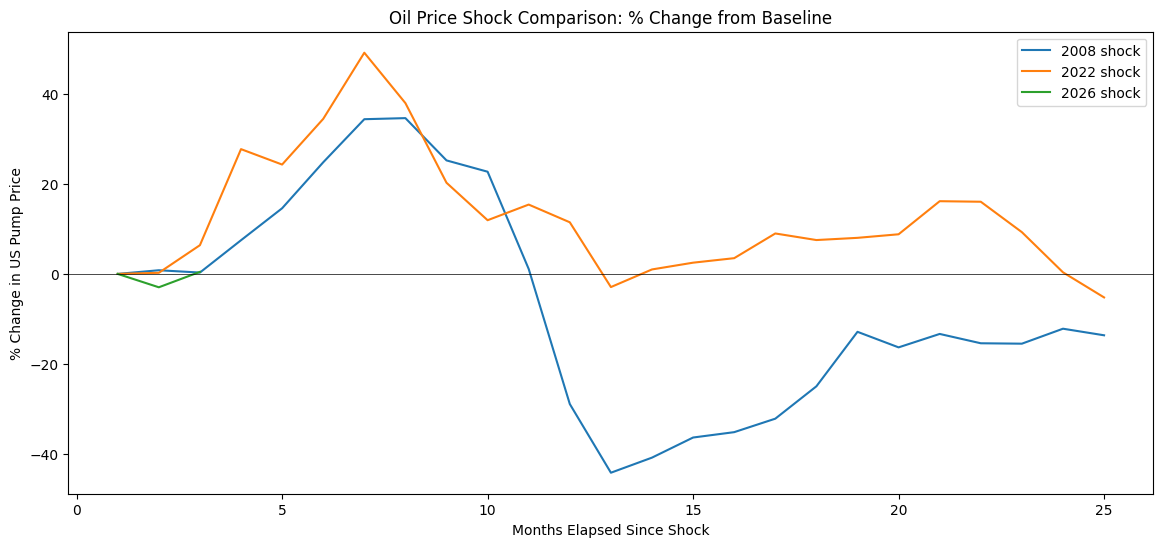

In [32]:
fig, ax = plt.subplots(figsize=(14,6))

for shock, group in df5.groupby('shock'):
    group.plot('months_elapsed', 'pct_change_from_baseline',
               ax=ax, label=shock)

ax.set_title('Oil Price Shock Comparison: % Change from Baseline')
ax.set_xlabel('Months Elapsed Since Shock')
ax.set_ylabel('% Change in US Pump Price')
ax.axhline(0, color='black', linewidth=0.5)

# Brent-to-pump delay

In [33]:
# Query US Brent LAG
query6 = """
select*,
avg_brent - LAG(avg_brent, 1) OVER (ORDER BY year_month) as brent_change_lag1,
avg_brent - LAG(avg_brent, 2) OVER (ORDER BY year_month) as brent_change_lag2,
avg_brent - LAG(avg_brent, 3) OVER (ORDER BY year_month) as brent_change_lag3
from
(select
  avg(e.us_regular) as avg_us,
  avg(b.brent_usd_bbl) as avg_brent,
  e.year_month
from eia_us_prices as e
join brent_crude as b on e.year_month = b.year_month
where us_regular is not null
group by e.year_month) as monthly_avg
"""

result = pd.read_sql_query(query6, conn)

In [34]:
df6 = pd.read_sql_query(query6, conn)
df6['pump_change'] = (df6['avg_us'] - df6['avg_us'].shift(1)) * 42

In [35]:
correlations = {
    'Same month': df6['pump_change'].corr(df6['avg_brent'] - df6['avg_brent'].shift(1)),
    'Lag 1 month': df6['pump_change'].corr(df6['brent_change_lag1']),
    'Lag 2 months': df6['pump_change'].corr(df6['brent_change_lag2']),
    'Lag 3 months': df6['pump_change'].corr(df6['brent_change_lag3'])
}

for k, v in correlations.items():
    print(f"{k}: {v:.4f}")

Same month: 0.7216
Lag 1 month: 0.7216
Lag 2 months: 0.7775
Lag 3 months: 0.6793


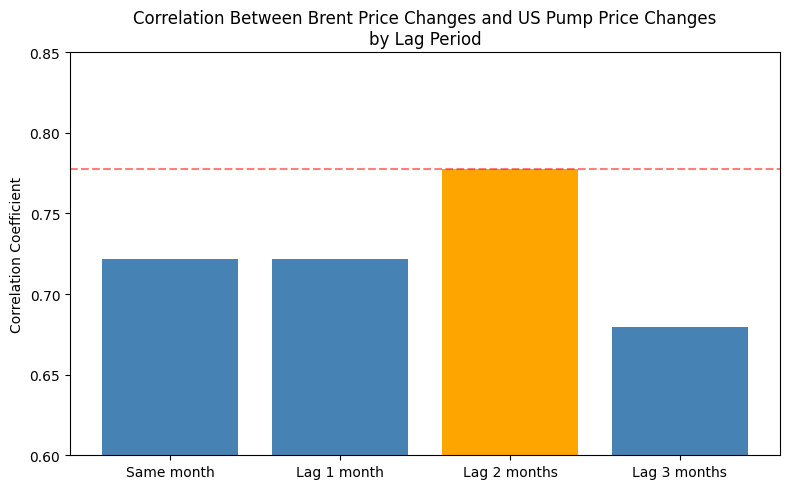

In [36]:
plt.figure(figsize=(8,5))
plt.bar(correlations.keys(), correlations.values(), color=['steelblue', 'steelblue', 'orange', 'steelblue'])
plt.title('Correlation Between Brent Price Changes and US Pump Price Changes\nby Lag Period')
plt.ylabel('Correlation Coefficient')
plt.ylim(0.6, 0.85)
plt.axhline(y=max(correlations.values()), color='red', linestyle='--', alpha=0.5)
plt.tight_layout()

# Shock Volatility

In [37]:
# Query US Brent LAG
query7 = """
select*,
case
  when year_month between '2007-12' and '2009-12' then'2008 shock'
  when year_month between '2021-12' and '2023-12' then'2022 shock'
  when year_month >= '2025-12' then '2026 shock'
  else 'no shock'
end as shock
from
(select
  avg(e.us_regular) as avg_us,
  avg(b.brent_usd_bbl) as avg_brent,
  e.year_month
from eia_us_prices as e
join brent_crude as b on e.year_month = b.year_month
where us_regular is not null
group by e.year_month) as monthly_avg
where shock != "no shock"
"""

result = pd.read_sql_query(query7, conn)
df7 = pd.read_sql_query(query7, conn)

In [38]:
volatility = df7.groupby('shock')[['avg_us', 'avg_brent']].std().round(4)
volatility.columns = ['pump_price_std', 'brent_std']
print(volatility)

            pump_price_std  brent_std
shock                                
2008 shock          0.7087    28.1056
2022 shock          0.4458    13.8326
2026 shock          0.0538     4.1755


# Graphs

In [41]:
import plotly.graph_objects as go

events = [
    {"date": pd.Timestamp("2008-06-01"), "label": "2008 Oil Crisis"},
    {"date": pd.Timestamp("2020-04-01"), "label": "COVID Low"},
    {"date": pd.Timestamp("2022-03-01"), "label": "Ukraine War"},
]

fig = go.Figure()

# US pump price (left axis)
fig.add_trace(go.Scatter(
    x=df1['year_month'],
    y=df1['avg_price'],
    name='US Regular ($/gal)',
    yaxis='y1',
    line=dict(color='#2563eb', width=2),
    hovertemplate='%{x|%b %Y}<br>US pump: $%{y:.2f}/gal<extra></extra>',
))

# Brent crude (right axis)
fig.add_trace(go.Scatter(
    x=df2['year_month'],
    y=df2['brent_usd_bbl'],
    name='Brent Crude ($/bbl)',
    yaxis='y2',
    line=dict(color='#f97316', width=2, dash='dot'),
    hovertemplate='%{x|%b %Y}<br>Brent: $%{y:.2f}/bbl<extra></extra>',
))

# Event annotations — shapes + annotations separately (avoids add_vline bug)
for ev in events:
    fig.add_shape(
        type='line',
        x0=ev["date"], x1=ev["date"],
        y0=0, y1=1,
        xref='x', yref='paper',
        line=dict(color='#dc2626', width=1.5, dash='dash'),
    )
    fig.add_annotation(
        x=ev["date"], y=1,
        xref='x', yref='paper',
        text=ev["label"],
        showarrow=False,
        xanchor='left',
        yanchor='top',
        font=dict(size=11, color='#dc2626'),
        bgcolor='rgba(255,255,255,0.7)',
        borderpad=3,
    )

fig.update_layout(
    title=dict(text='US retail gas vs Brent crude, 2000–2026', font=dict(size=15)),
    xaxis=dict(title='', showgrid=True, gridcolor='#f0f0f0'),
    yaxis=dict(
        title='US regular ($/gal)',
        titlefont=dict(color='#2563eb'),
        tickfont=dict(color='#2563eb'),
        showgrid=True,
        gridcolor='#f0f0f0',
    ),
    yaxis2=dict(
        title='Brent crude ($/bbl)',
        titlefont=dict(color='#f97316'),
        tickfont=dict(color='#f97316'),
        overlaying='y',
        side='right',
        showgrid=False,
    ),
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='left', x=0),
    hovermode='x unified',
    plot_bgcolor='#ffffff',
    paper_bgcolor='#ffffff',
    margin=dict(l=60, r=60, t=60, b=40),
    height=450,
)

fig.show()

In [42]:
events = [
    {"date": pd.Timestamp("2008-06-01"), "label": "2008 Oil Crisis"},
    {"date": pd.Timestamp("2020-04-01"), "label": "COVID Low"},
    {"date": pd.Timestamp("2022-03-01"), "label": "Ukraine War"},
]

fig = go.Figure()

# Ratio line
fig.add_trace(go.Scatter(
    x=df3['year_month'],
    y=df3['ratio'],
    name='Retail/crude ratio',
    line=dict(color='#7c3aed', width=2),
    fill='tozeroy',
    fillcolor='rgba(124, 58, 237, 0.07)',
    hovertemplate='%{x|%b %Y}<br>Ratio: %{y:.3f}<extra></extra>',
))

# Parity line at 1.0
fig.add_hline(
    y=1.0,
    line=dict(color='#9ca3af', width=1.2, dash='dash'),
    annotation_text='Parity (1.0)',
    annotation_position='right',
    annotation_font=dict(size=11, color='#9ca3af'),
)

# Event lines + labels
for ev in events:
    fig.add_shape(
        type='line',
        x0=ev["date"], x1=ev["date"],
        y0=0, y1=1,
        xref='x', yref='paper',
        line=dict(color='#dc2626', width=1.5, dash='dash'),
    )
    fig.add_annotation(
        x=ev["date"], y=1,
        xref='x', yref='paper',
        text=ev["label"],
        showarrow=False,
        xanchor='left',
        yanchor='top',
        font=dict(size=11, color='#dc2626'),
        bgcolor='rgba(255,255,255,0.7)',
        borderpad=3,
    )

fig.update_layout(
    title=dict(text='US retail-to-crude ratio, 2000–2026', font=dict(size=15)),
    xaxis=dict(title='', showgrid=True, gridcolor='#f0f0f0'),
    yaxis=dict(
        title='(US pump $/gal × 42) ÷ Brent $/bbl',
        showgrid=True,
        gridcolor='#f0f0f0',
    ),
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='left', x=0),
    hovermode='x unified',
    plot_bgcolor='#ffffff',
    paper_bgcolor='#ffffff',
    margin=dict(l=60, r=60, t=60, b=40),
    height=450,
)

fig.show()

In [44]:
# Split into quadrants
q1 = df4[(df4['brent_change'] >= 0) & (df4['pump_change'] >= 0)]  # both rise
q2 = df4[(df4['brent_change'] <  0) & (df4['pump_change'] >= 0)]  # crude falls, pump sticky
q3 = df4[(df4['brent_change'] <  0) & (df4['pump_change'] <  0)]  # both fall
q4 = df4[(df4['brent_change'] >= 0) & (df4['pump_change'] <  0)]  # crude rises, pump lags

quadrants = [
    (q1, '#2563eb', 'Q1 — both rise'),
    (q2, '#dc2626', 'Q2 — crude falls, pump sticky'),
    (q3, '#16a34a', 'Q3 — both fall'),
    (q4, '#f97316', 'Q4 — crude rises, pump lags'),
]

fig = go.Figure()

# Scatter points per quadrant
for df_q, color, name in quadrants:
    fig.add_trace(go.Scatter(
        x=df_q['brent_change'],
        y=df_q['pump_change'],
        mode='markers',
        name=f'{name} (n={len(df_q)})',
        marker=dict(color=color, size=7, opacity=0.5, line=dict(width=0)),
        hovertemplate=(
            '<b>' + name + '</b><br>'
            'Brent Δ: $%{x:.2f}/bbl<br>'
            'Pump Δ: $%{y:.2f}/bbl<extra></extra>'
        ),
    ))

# Regression line per quadrant
for df_q, color, name in quadrants:
    clean = df_q[['brent_change','pump_change']].dropna()
    if len(clean) < 2:
        continue
    m, b = np.polyfit(clean['brent_change'], clean['pump_change'], 1)
    x_range = np.linspace(clean['brent_change'].min(), clean['brent_change'].max(), 50)
    fig.add_trace(go.Scatter(
        x=x_range,
        y=m * x_range + b,
        mode='lines',
        line=dict(color=color, width=2),
        showlegend=False,
        hoverinfo='skip',
    ))

# Quadrant labels
label_offsets = [
    (8,  1.5,  'Q1: rockets'),
    (-8, 1.5,  'Q2: sticky up'),
    (-8, -1.5, 'Q3: feathers'),
    (8,  -1.5, 'Q4: sticky down'),
]
colors = ['#2563eb','#dc2626','#16a34a','#f97316']
for (x, y, txt), color in zip(label_offsets, colors):
    fig.add_annotation(
        x=x, y=y, text=txt,
        showarrow=False,
        font=dict(size=11, color=color),
        opacity=0.6,
    )

# Zero axes
fig.add_hline(y=0, line=dict(color='#1a1a1a', width=1))
fig.add_vline(x=0, line=dict(color='#1a1a1a', width=1))

fig.update_layout(
    title=dict(text='Rockets & feathers: Brent vs US pump price changes', font=dict(size=15)),
    xaxis=dict(title='Brent monthly change ($/bbl)', showgrid=True, gridcolor='#f0f0f0', zeroline=False),
    yaxis=dict(title='US pump monthly change ($/bbl)', showgrid=True, gridcolor='#f0f0f0', zeroline=False),
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='left', x=0),
    hovermode='closest',
    plot_bgcolor='#ffffff',
    paper_bgcolor='#ffffff',
    margin=dict(l=60, r=40, t=80, b=50),
    height=520,
)

fig.show()

In [45]:
import plotly.graph_objects as go

labels = ['Same month', 'Lag 1 month', 'Lag 2 months', 'Lag 3 months']
values = list(correlations.values())
peak   = max(values)
colors = ['#f97316' if v == peak else '#2563eb' for v in values]

fig = go.Figure()

fig.add_trace(go.Bar(
    x=labels,
    y=values,
    marker_color=colors,
    text=[f'{v:.3f}' for v in values],
    textposition='outside',
    hovertemplate='%{x}<br>Correlation: %{y:.4f}<extra></extra>',
))

# Peak reference line
fig.add_hline(
    y=peak,
    line=dict(color='#dc2626', width=1.5, dash='dash'),
    annotation_text=f'Peak: {peak:.3f}',
    annotation_position='right',
    annotation_font=dict(size=11, color='#dc2626'),
)

fig.update_layout(
    title=dict(text='Correlation between Brent price changes and US pump price changes by lag period', font=dict(size=15)),
    xaxis=dict(title='', showgrid=False),
    yaxis=dict(
        title='Correlation coefficient',
        range=[0.6, 0.88],
        showgrid=True,
        gridcolor='#f0f0f0',
    ),
    plot_bgcolor='#ffffff',
    paper_bgcolor='#ffffff',
    margin=dict(l=60, r=80, t=60, b=40),
    height=420,
    showlegend=False,
)

fig.show()